In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [7]:
df.isna().sum().sort_values(ascending=False)
df.duplicated().sum()
df = df.drop_duplicates()

In [8]:
df.describe()
df["DEATH_EVENT"].value_counts()
df["DEATH_EVENT"].value_counts(normalize=True)

,proportion
DEATH_EVENT,
0,0.67893
1,0.32107


In [10]:
#rata-rata umur pasian meninggal vs tidak
df.groupby("DEATH_EVENT")["age"].mean()
df.groupby("DEATH_EVENT")[["ejection_fraction","serum_creatinine","serum_sodium"]].mean()

binary_cols = ["anaemia","diabetes","high_blood_pressure","sex","smoking"]

for c in binary_cols:
  print("\n", c)
  print(df.groupby("DEATH_EVENT")[c].mean())


 anaemia
DEATH_EVENT
0    0.408867
1    0.479167
Name: anaemia, dtype: float64

 diabetes
DEATH_EVENT
0    0.418719
1    0.416667
Name: diabetes, dtype: float64

 high_blood_pressure
DEATH_EVENT
0    0.325123
1    0.406250
Name: high_blood_pressure, dtype: float64

 sex
DEATH_EVENT
0    0.650246
1    0.645833
Name: sex, dtype: float64

 smoking
DEATH_EVENT
0    0.325123
1    0.312500
Name: smoking, dtype: float64


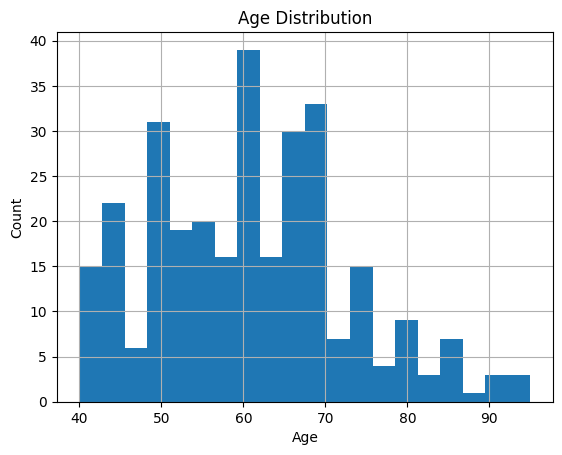

In [11]:
#histogram umur
plt.figure()
df["age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

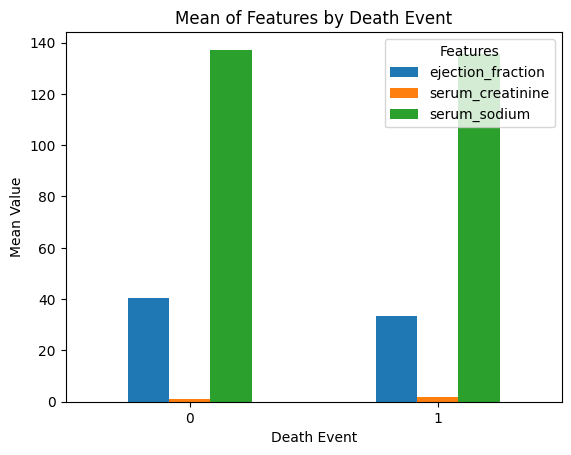

In [12]:
#rata-rata fitur vs death event
means = df.groupby("DEATH_EVENT")[["ejection_fraction","serum_creatinine","serum_sodium"]].mean()

plt.figure()
means.plot(kind="bar")
plt.title("Mean of Features by Death Event")
plt.xlabel("Death Event")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.show()

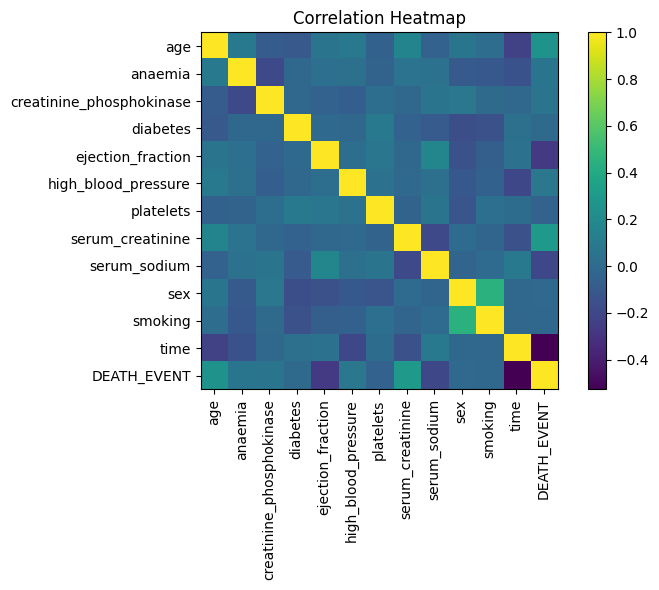

In [16]:
#heatmap
num_cols = df.select_dtypes(include=["number"]).columns
cor = df[num_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(cor, cmap="viridis")
plt.colorbar()
plt.xticks(range(len(cor.columns)), cor.columns, rotation=90)
plt.yticks(range(len(cor.columns)), cor.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
age_by_death = df.groupby(["DEATH_EVENT", "age"]).mean()
ef_by_death = df.groupby(["DEATH_EVENT", "ejection_fraction"]).mean()
scr_by_death = df.groupby(["DEATH_EVENT", "serum_creatinine"]).mean()

print("avg age (0=alive, 1=death):")
print(age_by_death)

print("\nAvg ejection_fraction:")
print(ef_by_death)

print("\nAvg serum_creatinine:")
print(scr_by_death)

avg age (0=alive, 1=death):
                   anaemia  creatinine_phosphokinase  diabetes  \
DEATH_EVENT age                                                  
0           40.0  0.285714                321.142857  0.285714   
            41.0  0.000000                148.000000  0.000000   
            42.0  0.166667               1017.833333  0.166667   
            43.0  1.000000                358.000000  0.000000   
            44.0  0.000000                333.000000  1.000000   
...                    ...                       ...       ...   
1           86.0  0.000000                582.000000  0.000000   
            87.0  1.000000                149.000000  0.000000   
            90.0  1.000000                 53.500000  0.500000   
            94.0  0.000000                582.000000  1.000000   
            95.0  1.000000                241.500000  0.000000   

                  ejection_fraction  high_blood_pressure      platelets  \
DEATH_EVENT age                       